**Autor: Emilio Hermosa Schiantarelli** 

**NIA: 100451150**

**Correo: 100451150@alumnos.uc3m.es**

# Cuaderno sobre sostenibilidad en ciudades inteligentes: Datos de contaminacion aerea.
__Objetivos generales__

1. Importar datos sobre contaminacion en Madrid.  

2.  Estudiar la estacionalidad representando diagramas de caja (O3 y NO).  

3. Estudiar la tendencia interanual con ventanas deslizantes (O3 y NO).  

4. Prediccion autoregresiva de valores medios semanales de O3  utilizando GP simples.

5. Comentar resultados.


## Importar librerías

El primer paso de la práctica es importar tanto las librerías necesarias así como los datos de la base de datos de Kaggle que se especifica en el eunciado. Dado que el enunciado que se nos ha dado es bastante explicativo he decidido ser lo más fiel posible a las indicaciones del mismo. Aún así, se verán importadas librerías adicionales a las recomendadas al inicio del enunciado así como otros pequeños cambios que he ido considerando oportunos.

En este primer apartado se importan las librerías necesarias para la práctica. Además, como método preventivo se ha añadido una línea al final para ignorar los posibles warnings y que así no se llenen las salidas de las celdas de warnings irrelevantes.

In [1]:
## IMPORTACION DE LOS DATOS DESDE KAGGLE E IMPORTACION DE LIBRERIAS

# Importar librerías necesarias
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
import torch
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.means import ConstantMean
from gpytorch.kernels import ScaleKernel, RBFKernel
from gpytorch.distributions import MultivariateNormal
from gpytorch.likelihoods import GaussianLikelihood
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

## Preprocesamiento de datos

Aunque es verdad que existen métodos para descargar automáticamente de Kaggle el csv, en mi caso lo descargué manualmente y lo leo tal y como se recomienda en el enunciado. Aunque se recomendaba usar Google Collab desarrollé la práctica en local. 

Se cargaron los datos y posteriormente se hicieron la selección de variables y transformaciones recomendada. Es por eso que en primer lugar se fuerza a que la frecuencia de la serie temporal se fije a una hora, se seleccionan ls variables NO y O3 en el periodo a estudiar (2006-2022) y por último como se especifica en el enunciado se tratan los datos faltantes con el valor medio de la serie temporal por simplicidad.

In [2]:
## PREPROCESAMIENTO DE LOS DATOS

# Cargar datos desde CSV con configuración recomendada
df = pd.read_csv('MadridPolution2001-2022.csv', index_col=0, parse_dates=True)

# Forzar frecuencia horaria (1H) para completar datos faltantes
df = df.asfreq('1h')

# Seleccionar contaminantes NO y O3
df = df[['NO', 'O3']]

# Seleccionar período 2006-2022
df = df['2006':'2022']

# Rellenar valores faltantes (NaN) con la media de cada columna
df = df.apply(lambda x: x.fillna(x.mean()) if x.name != 'Time' else x, axis=0)

# Verificar estructura de datos
print("Forma del dataframe:", df.shape)
print("Rango temporal:", df.index.min(), "a", df.index.max())
print("Valores faltantes:")
print(df.isnull().sum())
print("\nPrimeras filas:")
print(df.head())

Forma del dataframe: (142416, 2)
Rango temporal: 2006-01-01 00:00:00+00:00 a 2022-03-31 23:00:00+00:00
Valores faltantes:
NO    0
O3    0
dtype: int64

Primeras filas:
                             NO    O3
Time                                 
2006-01-01 00:00:00+00:00  11.0  37.0
2006-01-01 01:00:00+00:00  31.0  24.0
2006-01-01 02:00:00+00:00  34.0  24.0
2006-01-01 03:00:00+00:00  23.0  29.0
2006-01-01 04:00:00+00:00  21.0  29.0


Como podemos comprobar, tras las transformaciones, selección de variables y limpieza de datos se nos queda un dataframe con tres columnas,Time, NO y O3 y con cero datos faltantes.

# Patrones de estacionalidad

Se nos pide intentar identificar patrones de estacionalidad en los datos. Para ello se crean cuatro boxplots:
1. Boxplot dónde cada caja agrupa las muestras por día de la semana para NO
2. Boxplot dónde cada caja agrupa las muestras por mes del año para NO
3. Boxplot dónde cada caja agrupa las muestras por día de la semana para O3
4. Boxplot dónde cada caja agrupa las muestras por mes del año para O3

Siguiendo las instrucciones del enunciado se prepara el dataframe para crear las boxplots que representen lo qe se nos pide, calculando el percil 95 (así se excluye el 1-5% superior) y se muestran los gráficos de las boxplots.

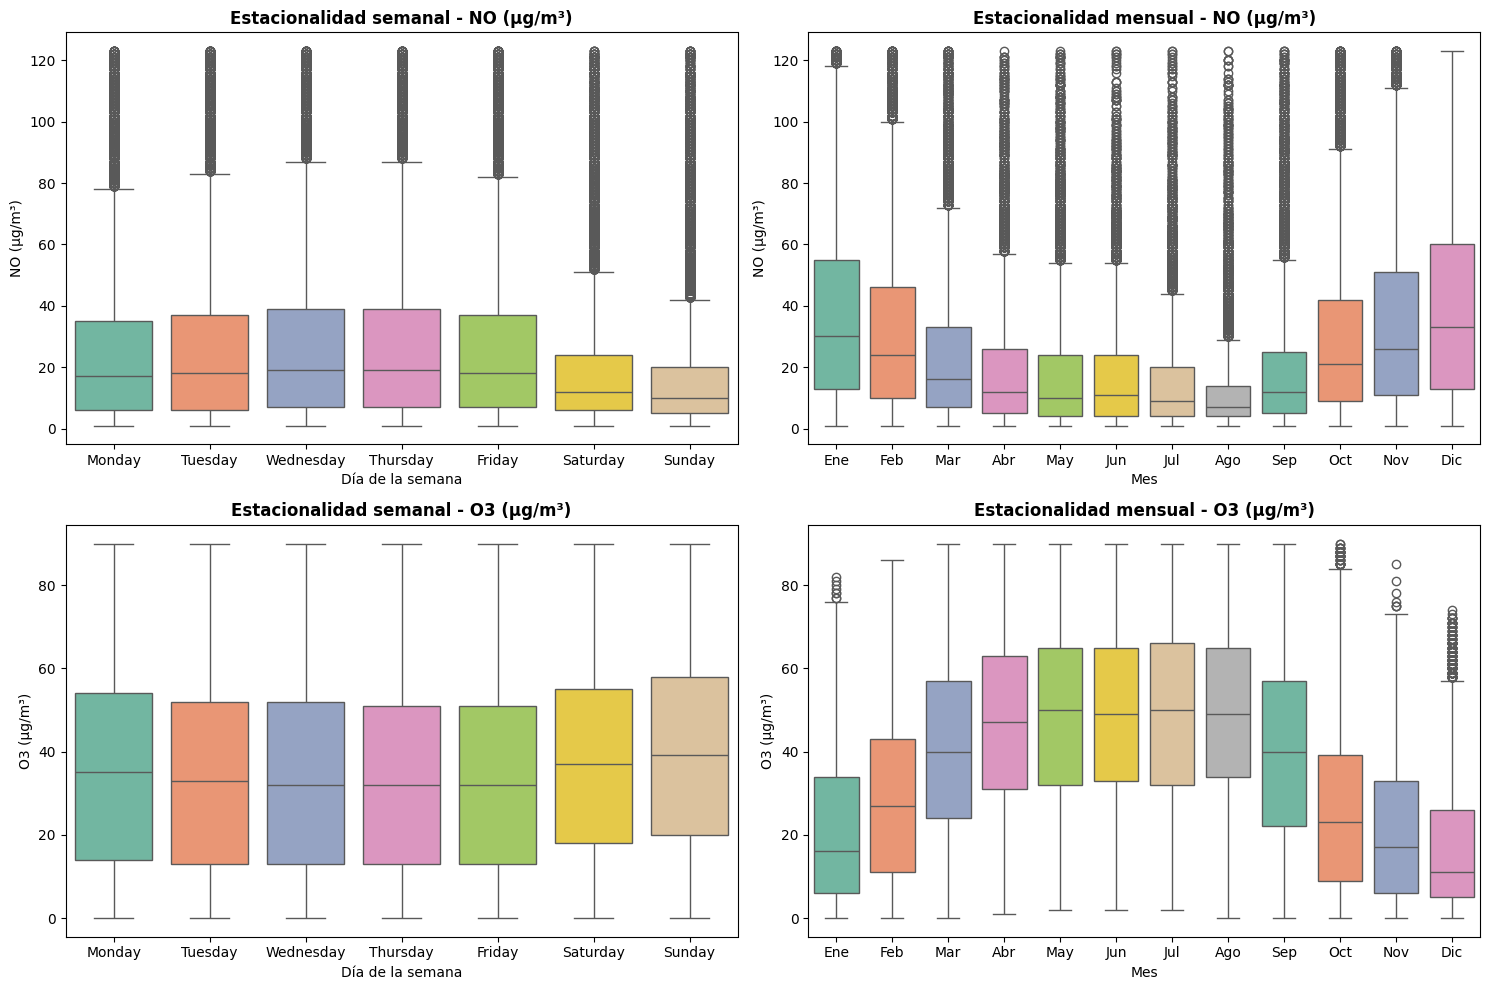

In [3]:
## REPRESENTACION DE BOXPLOTS MENSUALES Y SEMANALES PARA NO Y O3. (4 EN TOTAL)

# Crear columnas con etiquetas temporales
df['Mes'] = df.index.month
df['Día'] = df.index.dayofweek

# Definir orden de días de la semana (0=Monday, 6=Sunday) 
dias_nombres = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orden_dias = [0, 1, 2, 3, 4, 5, 6]

# Definir orden de meses del año (1=Enero, 12=Diciembre).
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
orden_meses = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Calcular percentil 95 para excluir outliers (1-5% superior)
percentil_95_NO = df['NO'].quantile(0.95)
percentil_95_O3 = df['O3'].quantile(0.95)

# Crear figura con 4 subgráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Boxplot semanal para NO
df_NO_sem = df[df['NO'] <= percentil_95_NO]
sns.boxplot(data=df_NO_sem, x='Día', y='NO', order=orden_dias, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Estacionalidad semanal - NO (µg/m³)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Día de la semana')
axes[0, 0].set_ylabel('NO (µg/m³)')
axes[0, 0].set_xticklabels(dias_nombres)

# 2. Boxplot mensual para NO
df_NO_mes = df[df['NO'] <= percentil_95_NO]
sns.boxplot(data=df_NO_mes, x='Mes', y='NO', order=orden_meses, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Estacionalidad mensual - NO (µg/m³)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('NO (µg/m³)')
axes[0, 1].set_xticklabels(meses_nombres)

# 3. Boxplot semanal para O3
df_O3_sem = df[df['O3'] <= percentil_95_O3]
sns.boxplot(data=df_O3_sem, x='Día', y='O3', order=orden_dias, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Estacionalidad semanal - O3 (µg/m³)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Día de la semana')
axes[1, 0].set_ylabel('O3 (µg/m³)')
axes[1, 0].set_xticklabels(dias_nombres)

# 4. Boxplot mensual para O3
df_O3_mes = df[df['O3'] <= percentil_95_O3]
sns.boxplot(data=df_O3_mes, x='Mes', y='O3', order=orden_meses, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Estacionalidad mensual - O3 (µg/m³)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('O3 (µg/m³)')
axes[1, 1].set_xticklabels(meses_nombres)

plt.tight_layout()
plt.show()

### Conclusiones de los boxplots

En este caso, como se puede ver en las boxplots, existen sobretodo patrones anuales que se ven fuertemente reflejados en las boxplots entre meses. Aún así, también para las box plots de días de la semana se puede encontrar cierto patrón intrasemana. La primera conclusión que se puede sacar comparand las boxplots de NO y O3 es que no se comportan igual, sino que sus patrones son opuestos tanto para el caso de días de semana como para el de meses del año. 

**Patrón intrasemana**: Para este caso, aunque no resalta quizá tanto como en el de los meses del año, se puede observar como NO es más alto en días entre semana (luneas a viernes) mientras que baja considerablemente en los días de fin de semana. Para O3 es lo contrario, en los días entre semana es ligeramente más bajo O3 mientras que sube en los días de fin de semana. Aún así, en O3 se puede ver como el lunes también permanece con un O3 ligeramente más alto que el resto de días entre semana. 

Esto me permite concluir que NO es altamente probable que esté ligado al tráfico y la actividad humana ya que en los días entre semana mucha más gente usa vehículos para ir al trabajo o colegios mientras que los fines de semana se reduce la cantidad de emisiones por vehículos dado que la gente no trabaja ni va a clase. Es por esto que cuanto más se usa el coche mayor es NO, por eso se ve reducido en fin de semana. Para O3 es al revés, menor uso de vehículos provoca que disminuya el NO y que directamente aumente ligeramente el O3. Como sé que O3 es el ozono, sé que al aumentar NO esto tiene un impacto inversamente proporcional en O3 lo que me hace deducir que NO consume O3 en la atmósfera.


**Patron anual**: En este caso se puede ver más clarmente la relación inversamente proporcional entre NO y O3. Además que hay un claro patrón estacional. Para NO se puede ver como es más alta su concentración en meses fríos y más bajo en los meses de verano. Por el contrario O3 tiene concentraciones más altas en meses más calurosos y a medida que hace más frío su concentración baja. La razón que se me ha ocurrido por lo que sucede esto es porque la radiación solar y el calor (más notables en meses de verano) provocan un aumento de ozono (O3) mientras que NO es favorecido por condiciones que se ajustan más a meses fríos donde la radiación solar no tiene tanto impacto.

**Nota**: quiero aclarar que dado que el enunciado decía que se dieran razones especulativas he decidido ceñirme a ello y no dar detalles más concretos de las posibles causas dado que investigando un poco y con la ayuda de LLMs rápidamente se pueden encontrar las razones reales y precisas de por qué pasa, y se podría entrar en detalle en conceptos como el **Ciclo de Leighton** que explica la reacción que justifica porque NO consume O3 u otras conclusiones más técnicas como que en invierno hay **peor dispersión** lo cuál hace que los contaminantes se dispersen peor y se concentren más cerca del suelo. Dado que el enunciado dice que se hablen de las razones especulativas únicamente he visto conveniente ceñirme a ello y no entrar en profundidad en unas conclusiones más técnicas.



## Representación de tendencia
El siguiente paso es representar una media móvil anual para No y O3 en un mismo gráfico para hacer una comparativa de los mismos. 

Siguiendo las indicaciones del enunciado mi ventana móvuil tiene 365*24 observaciones y se utiliza una función que ya utilicé en la asignatura de IA en Finanzas para calcular medias móviles que es **rolling()**.

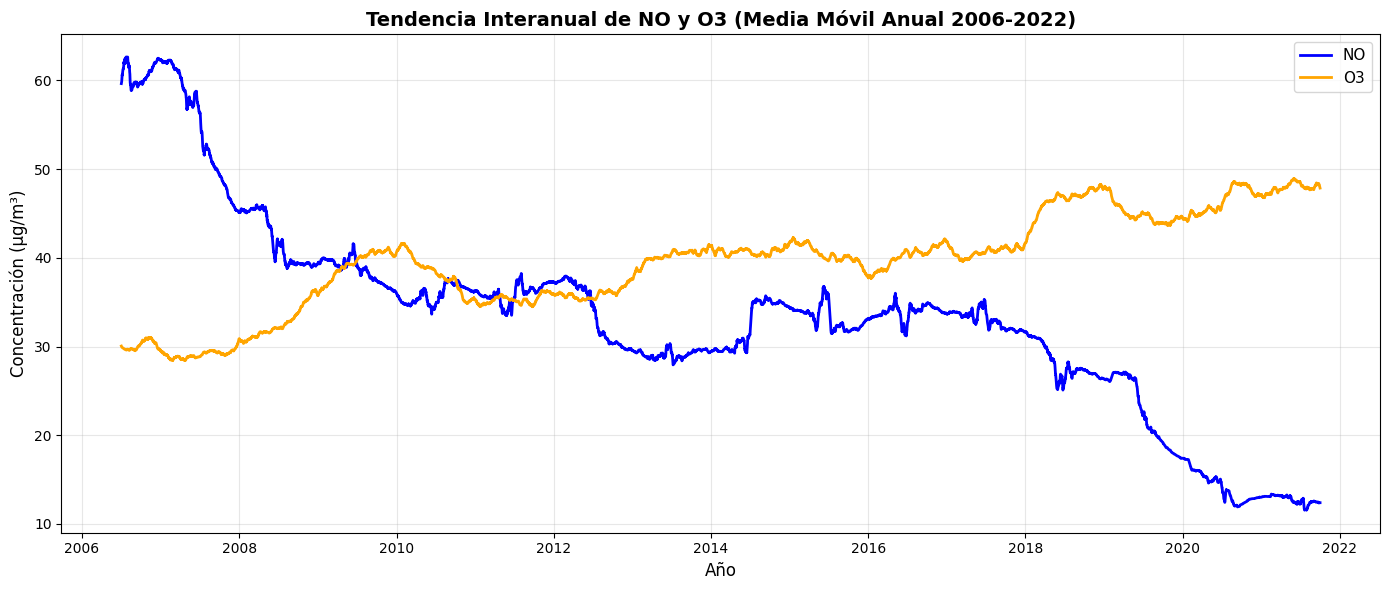

Tendencia anual calculada con ventana de 8760 observaciones horarias


In [4]:
## REPRESENTACION DE TENDENCIA (MEDIA MOVIL ANUAL) PARA NO Y O3 EN UN MISMO GRAFICO

# Calcular media móvil anual
ventana = 365 * 24

# Crear copia de datos originales para calcular media móvil
df_original = df[['NO', 'O3']].copy()

# Calcular media móvil
media_movil_NO = df_original['NO'].rolling(window=ventana, center=True).mean()
media_movil_O3 = df_original['O3'].rolling(window=ventana, center=True).mean()

# Crear figura
fig, ax = plt.subplots(figsize=(14, 6))

# Graficar tendencias
ax.plot(media_movil_NO.index, media_movil_NO, label='NO', linewidth=2, color='blue')
ax.plot(media_movil_O3.index, media_movil_O3, label='O3', linewidth=2, color='orange')

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Concentración (µg/m³)', fontsize=12)
ax.set_title('Tendencia Interanual de NO y O3 (Media Móvil Anual 2006-2022)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Tendencia anual calculada con ventana de", ventana, "observaciones horarias")

### Conclusiones de medias móviles
En este caso se puede observar claramente como para NO hay un descenso continuo entre 2006 y 2022 lo cuál indica una mejora en la calidad del aire respecto a NO. Se presupone que sea entre otras cosas gracias a las iniciativas de reducción de emisiones de tráfico por ejemplo. Para O3 en cambio se ve todo lo contrario, hay un tendencia ascendente del O3, lo cuál indica que a diferencia de NO empeora el ozono, las causas de esto pueden ser el calentamiento global o la radiación solar. Esta relación inversamente proporcional ya se comentaba antes.

Esto nos hace ver que una reducción de NO no basta para que se reduzca O3 y que se debe profundizar y dar más importancia a iniciativas que reduzcan el ozono.

## Preparación de datos para modelo
El siguiente paso de la práctica es crear un modelo que permita realizar la predicción del ozono. Para ello se focaliza en los datos entre 2006 y 2020. Siendo los datos entre 2006 y 2016 usados para el entrenamiento del modelo y los datos entre 2017 y 2020 usados para la predicción.

Por estas razones se vuelve a hacer una preparación de los datos, obteniendo un dataframe solo con los valores de O3 y siguiendo los pasos específicos del enunciado.

Aunque el enunciado compartía una posible solución para reorganizar datos para generar un modelo autoregresivo como [AR](https://gist.github.com/monocongo/6e0df19c9dd845f3f465a9a6ccfcef37), decidí simplificarlo gracias ya que la única variable a predecir es O3. Además también se estandarizan los datos tal y como se recomendaba en el enunciado.

In [5]:
## PREPARACION DE LOS DATOS PARA REGRESION

# 1. Promediar valores semanales de O3 (52 valores por año)
df_original_clean = df[['O3']].copy()
O3_semanal = df_original_clean['O3'].resample('W').mean()

print("Número total de semanas en el dataset:", len(O3_semanal))
print("Primeras semanas:", O3_semanal.head())

# Dividir por períodos exactos (igual que hicimos con los datos horarios)
O3_train = O3_semanal['2006':'2016']
O3_test = O3_semanal['2017':'2020']

print(f"\nPeríodo entrenamiento: {O3_train.index.min()} a {O3_train.index.max()}")
print(f"Periodo test: {O3_test.index.min()} a {O3_test.index.max()}")
print(f"Semanas en entrenamiento: {len(O3_train)}")
print(f"Semanas en test: {len(O3_test)}")

# 2. Reorganizar datos para crear modelo autoregresivo
# Entrada: (x(t-1), x(t-2), ..., x(t-k)) -> Salida: x(t)
k = 5  # número de pasos anteriores a usar

def crear_secuencias_autoregresivas(datos, k):
    """Crear secuencias autoregresivas para predicción"""
    datos_array = datos.values  # Convertir a numpy array para acceso pos posición
    X, y = [], []
    for i in range(k, len(datos_array)):
        X.append(datos_array[i-k:i])
        y.append(datos_array[i])
    return np.array(X), np.array(y)

X_train, y_train = crear_secuencias_autoregresivas(O3_train, k)
X_test, y_test = crear_secuencias_autoregresivas(O3_test, k)

print(f"\nForma de X_train: {X_train.shape}, Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}, Forma de y_test: {y_test.shape}")

# 3. Estandarizar datos usando estadísticas del conjunto de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Estandarizar y con media y desviación estándar del entrenamiento
y_mean, y_std = y_train.mean(), y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print(f"\nDatos estandarizados:")
print(f"Media de y_train_scaled: {y_train_scaled.mean():.6f}")
print(f"Desviación estándar de y_train_scaled: {y_train_scaled.std():.6f}")

# Guardar información de escalado para usar en predicción
print("\nInfo de escalado guardada para uso posterior")

Número total de semanas en el dataset: 849
Primeras semanas: Time
2006-01-01 00:00:00+00:00    30.885245
2006-01-08 00:00:00+00:00    14.392661
2006-01-15 00:00:00+00:00    11.676912
2006-01-22 00:00:00+00:00    11.992388
2006-01-29 00:00:00+00:00    19.288249
Freq: W-SUN, Name: O3, dtype: float64

Período entrenamiento: 2006-01-01 00:00:00+00:00 a 2016-12-25 00:00:00+00:00
Periodo test: 2017-01-01 00:00:00+00:00 a 2020-12-27 00:00:00+00:00
Semanas en entrenamiento: 574
Semanas en test: 209

Forma de X_train: (569, 5), Forma de y_train: (569,)
Forma de X_test: (204, 5), Forma de y_test: (204,)

Datos estandarizados:
Media de y_train_scaled: -0.000000
Desviación estándar de y_train_scaled: 1.000000

Info de escalado guardada para uso posterior


**Nota**: Para los datos de **y** se hace la estandarización manual dado que posteriormente se utilizarán la media y desviación típica en otros apartados y así puedo aprovechar esas variables.

## Predicción con procesos gausianos
Para este apartado de la práctica he utilizado GPyTorch dado que el enunciado especificaba claramente que únicamente se otorgarí la nta completa si se utilizaba dicha librería. Me basé en la documentación encontrada en [GPyTorch Tutorial](https://docs.gpytorch.ai/en/stable/examples/01_Exact_GPs/Simple_GP_Regression.html) para la implementación de la clase y el entrenamiento del modelo.

Además también se ha seguido el caso de ejemplo del tutorial para el proceso de evaluación y predicciones.

In [6]:
## PREDICCION CON PROCESOS GAUSIANOS (R2>0.7)

# Convertir datos a tensores de PyTorch
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_torch = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_torch = torch.tensor(y_test_scaled, dtype=torch.float32)

# Definir modelo de Proceso Gaussiano con GPyTorch
class GaussianProcessModel(ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GaussianProcessModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel())
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

# Crear modelo y likelihood (ruido Gaussiano homocedástico)
likelihood = GaussianLikelihood()
gp_model = GaussianProcessModel(X_train_torch, y_train_torch, likelihood)

# Modo entrenamiento
gp_model.train()
likelihood.train()

# Optimizador y función de pérdida
optimizer = torch.optim.Adam(gp_model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gp_model)

# Entrenar el modelo
print("Entrenando modelo de Procesos Gaussianos con GPyTorch...")
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = gp_model(X_train_torch)
    loss = -mll(output, y_train_torch)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Época {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

print("Entrenamiento completado.")

# Modo evaluación
gp_model.eval()
likelihood.eval()

# Realizar predicciones en conjunto de test
with torch.no_grad():
    predictions = likelihood(gp_model(X_test_torch))
    y_pred_scaled = predictions.mean.numpy()
    y_std_pred = predictions.stddev.numpy()

# Desescalar predicciones
y_pred = y_pred_scaled * y_std + y_mean
y_std_pred_original = y_std_pred * y_std

# Calcular métrica de rendimiento
r2_score_value = r2_score(y_test, y_pred)

print(f"\n--- RESULTADOS DEL MODELO ---")
print(f"R² Score en test: {r2_score_value:.4f}")

if r2_score_value > 0.7:
    print(f"✓ Modelo satisface requisito R² > 0.7")
else:
    print(f"✗ Modelo NO satisface requisito R² > 0.7")

print(f"\nModelo: Proceso Gaussiano con GPyTorch")
print(f"Kernel: RBF (Radial Basis Function)")
print(f"Ruido: Gaussiano homocedástico")

Entrenando modelo de Procesos Gaussianos con GPyTorch...
Época 20/100, Loss: 0.7366
Época 40/100, Loss: 0.7183
Época 60/100, Loss: 0.7135
Época 80/100, Loss: 0.7122
Época 100/100, Loss: 0.7116
Entrenamiento completado.

--- RESULTADOS DEL MODELO ---
R² Score en test: 0.7556
✓ Modelo satisface requisito R² > 0.7

Modelo: Proceso Gaussiano con GPyTorch
Kernel: RBF (Radial Basis Function)
Ruido: Gaussiano homocedástico


Dado que el enunciado de la práctica dice que el único requisito es que R² sea mayor que 0.7 se ha tomado eso como base y se ha creado un modelo basado en esta limitación.

## Resultados

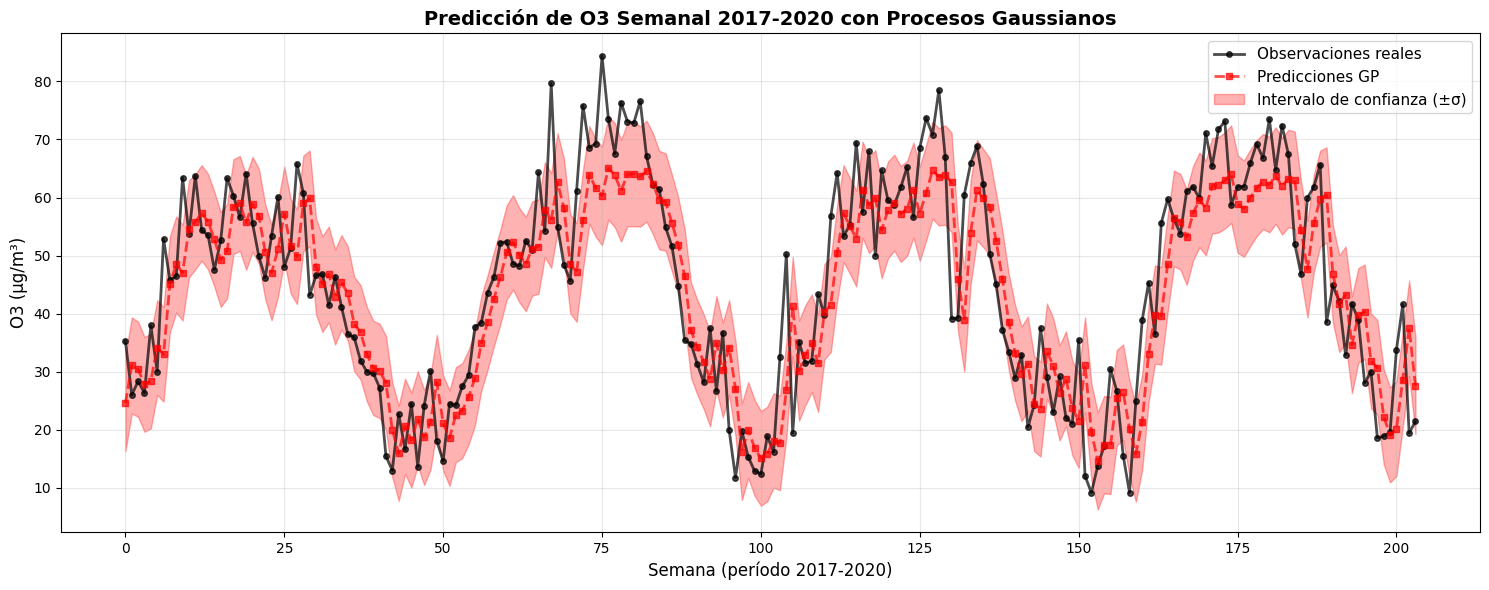

Número de predicciones: 204
Rango de valores predichos: [14.62, 65.05]
Rango de valores reales: [9.13, 84.38]


In [7]:
## GRAFICA DE PREDICCION: VALORES SEMANALES DE O3 2017-2020

# Crear índices de tiempo para el conjunto de test
# Los índices corresponden a semanas dentro del período 2017-2020
indices_test = np.arange(len(y_test))

# Crear figura con gran tamaño
fig, ax = plt.subplots(figsize=(15, 6))

# Graficar observaciones reales
ax.plot(indices_test, y_test, 'o-', label='Observaciones reales', 
        color='black', linewidth=2, markersize=4, alpha=0.7)

# Graficar predicciones
ax.plot(indices_test, y_pred, 's--', label='Predicciones GP', 
        color='red', linewidth=2, markersize=4, alpha=0.7)

# Graficar intervalo de confianza (±σ)
ax.fill_between(indices_test, 
                y_pred - y_std_pred_original, 
                y_pred + y_std_pred_original, 
                alpha=0.3, color='red', label='Intervalo de confianza (±σ)')

ax.set_xlabel('Semana (período 2017-2020)', fontsize=12)
ax.set_ylabel('O3 (µg/m³)', fontsize=12)
ax.set_title('Predicción de O3 Semanal 2017-2020 con Procesos Gaussianos', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Número de predicciones: {len(y_pred)}")
print(f"Rango de valores predichos: [{y_pred.min():.2f}, {y_pred.max():.2f}]")
print(f"Rango de valores reales: [{y_test.min():.2f}, {y_test.max():.2f}]")

In [8]:
## COMPUTAR INTERVALO DE CONFIANZA. ¿ENTRA DENTRO DE LO ESPERADO? JUSTIFICA TU RESPUESTA.

# Calcular límites del intervalo de confianza (±σ)
limite_superior = y_pred + y_std_pred_original
limite_inferior = y_pred - y_std_pred_original

# Verificar qué observaciones caen dentro del intervalo de confianza
dentro_intervalo = (y_test >= limite_inferior) & (y_test <= limite_superior)

# Calcular porcentaje de muestras dentro del intervalo
num_dentro = np.sum(dentro_intervalo)
total_muestras = len(y_test)
porcentaje_dentro = (num_dentro / total_muestras) * 100

# Valor esperado teórico para ±1σ es ~68% (en distribución normal)
valor_esperado = 68.0
diferencia = porcentaje_dentro - valor_esperado

print("="*60)
print("ANÁLISIS DEL INTERVALO DE CONFIANZA (±σ)")
print("="*60)
print(f"\nMuestras totales en conjunto de test: {total_muestras}")
print(f"Muestras dentro del intervalo [ŷ - σ, ŷ + σ]: {num_dentro}")
print(f"Porcentaje dentro del intervalo: {porcentaje_dentro:.2f}%")
print(f"Valor esperado teórico (±1σ): ~{valor_esperado}%")
print(f"Diferencia: {diferencia:+.2f}%")

ANÁLISIS DEL INTERVALO DE CONFIANZA (±σ)

Muestras totales en conjunto de test: 204
Muestras dentro del intervalo [ŷ - σ, ŷ + σ]: 131
Porcentaje dentro del intervalo: 64.22%
Valor esperado teórico (±1σ): ~68.0%
Diferencia: -3.78%


### Conclusiones de los resultados obtenidos
En base a la gráfica podemos concluir que el modelo hace un buen seguimiento de la tendencia, el modelo es capaz de predecir con astante precisión las observaciones reales. Se puede ver como los patrones estacionales que veíamos en la boxplot de O3 para los meses del año se aprecian también en la gráfica mostrada en el resultado y como el modelo ha captado bien estos patrones donde O3 sube en épocas calurosas y disminuye en épocas frías.

Aún así el modelo suele predecir un valor más bajo que el real lo que indica que subestima los picos reales. Esto es normal dado que es un modelo autoregresivo que promedia y se basa en el comportamiento histórico.

Como se puede ver además en el intervalo de confianza, este es de 64.22%. Lo consulté con el profesor en clase y me dijo que era un resultado más que suficiente teniend en cuenta que el valor teórico esperado en la práctica es alrededor de 68% por lo que como se ve en el resultado la diferencia es de -3.78%. Además el modelo es capaz de explicar más del 70% de la varianza en los datos de test (R²>0.7) dando así un rendimiento aceptable para los objetivos de la práctica.